P=2.001 МПа, T=270.0 K
K_calc=0.9521, K_test=0.9521


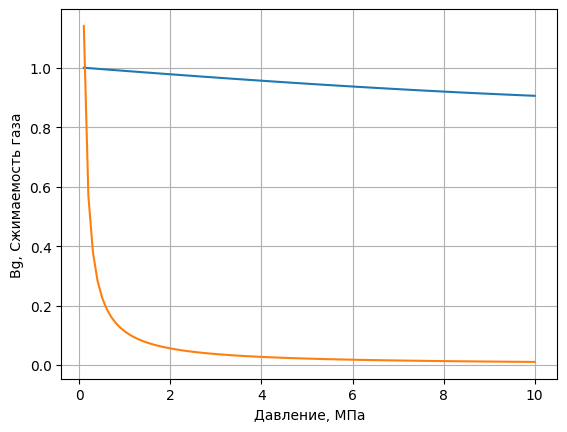

In [133]:

import numpy as np
import matplotlib.pyplot as plt

class Fluid:
    
    Pstd = 101325       # стандартное давление, Па
    Tstd = 293.15  # стандартная температура, К
    
    def __init__(self, rho_c: float, xa: float, xy: float):
        self.rho_c = rho_c
        #Перевод д.ед
        self.xa = xa/100 
        self.xy = xy/100 
        
    def get_Z(self, P: float, T: float):
        #Расчет фактора сжимаемости при стандартных условиях (z_c)
        z_c = 1-(0.0741*self.rho_c-0.006-0.063*self.xa-0.0575*self.xy)**2
        #Расчет молярной доли эквивалентного углеводорода (x_u в д.ед)
        x_u = 1 - self.xa - self.xy
        #Расчет молярной массы эквивалентного угле-да (M_u в д.ед)
        M_u = (24.05525*z_c*self.rho_c-28.0135*(self.xa)-44.01*(self.xy))/x_u
        #Расчет H
        H = 128.64+47.479*M_u
        #Расчет молярной плотности rho_m в кмоль/м3
            #Молярная масса газа в кг/кмоль
        M_g = M_u*x_u+28.0135*(self.xa)+44.01*(self.xy)
            #Тогда моляная плотность будет рассчитана
        rho_m = (self.rho_c/M_g)
        #Расчет коэфф-ов B1,B2 и т.д.
        B1 = (-0.425468 + 2.865e-3*T - 4.62073e-6*T**2 + (8.77118e-4 - 5.56281e-6*T + 8.8151e-9*T**2)*H
          + (-8.24747e-7 + 4.31436e-9*T - 6.08319e-12*T**2)*H**2)
        B2 = -0.1446 + 7.4091e-4*T - 9.1195e-7*T**2
        B23 = -0.339693 + 1.61176e-3*T - 2.04429e-6*T**2
        B3 = -0.86834 + 4.0376e-3*T - 5.1657e-6*T**2
        C1 = (-0.302488 + 1.95861e-3*T - 3.16302e-6*T**2
              + (6.46422e-4 - 4.22876e-6*T + 6.88157e-9*T**2)*H
              + (-3.32805e-7 + 2.2316e-9*T - 3.67713e-12*T**2)*H**2)
        C2 = 7.8498e-3 - 3.9895e-5*T + 6.1187e-8*T**2
        C3 = 2.0513e-3 + 3.4888e-5*T - 8.3703e-8*T**2
        C223 = 5.52066e-3 - 1.68609e-5*T + 1.57169e-8*T**2
        C233 = 3.58783e-3 + 8.06674e-6*T - 3.25798e-8*T**2
        B_star = 0.72 + 1.875e-5*(320 - T)**2
        C_star = 0.92 + 0.0013*(T - 270)
        Bm = (x_u**2 * B1 + x_u *  self.xa * B_star * (B1 + B2) - 1.73 * x_u *  self.xy * (B1 * B3)**0.5 
          +  self.xa**2 * B2 + 2 *  self.xa *  self.xy * B23 +  self.xy**2 * B3)
        Cm = (x_u**3 * C1 + 3 * x_u**2 *  self.xa * C_star * (C1**2 * C2)**(1/3) + 2.76 * x_u**2 *  self.xy * (C1**2 * C3)**(1/3)
          + 3 * x_u *  self.xa**2 * C_star * (C1 * C2**2)**(1/3) + 6.6 * x_u *  self.xa *  self.xy * (C1 * C2 * C3)**(1/3)
          + 2.76 * x_u *  self.xy**2 * (C1 * C3**2)**(1/3) +  self.xa**3 * C2 + 3 *  self.xa**2 *  self.xy * C223
          + 3 *  self.xa * self.xy**2 * C233 +  self.xy**3 * C3)
        b = 10**3 * (P / (2.7715*T)) # Р, МПа
        C0 = b**2 * Cm
        B0 = b * Bm
        A1 = 1 + B0
        A0 = 1 + 1.5 * (B0 + C0)
        A2 = (A0 - (A0**2 - A1**3)**0.5)**(1/3)
        #Подстановка в итоговую формулу
        Z = (1 + A2 + A1/A2) / 3
        K = Z / z_c
        return K

    def get_Bg(self, P: float, T: float):
        Bg = (self.Pstd * self.get_Z(P, T) * T) / ((P*10**6) * self.Tstd)
        return Bg
        
    def plot_Z(self, T_fixed=310):
        p = np.linspace(0.1, 10, 100)
        z_plot = self.get_Z(p, T)
        plt.plot(p, z_plot)
        plt.xlabel('Давление, МПа')
        plt.ylabel('Сжимаемость газа')
        plt.grid(True)
        return()
        
    def plot_Bg(self, T_fixed=310):
        p = np.linspace(0.1, 10, 100)
        Bg_plot = self.get_Bg(p, T)
        plt.plot(p, Bg_plot)
        plt.xlabel('Давление, МПа')
        plt.ylabel('Bg, Сжимаемость газа')
        plt.grid(True)
 # Проверка с табличными значениями
f = Fluid(rho_c=0.6799, xa=0.8858, xy=0.0668)
# Меняем значения на табличные для проверки
P_test = 2.001  # МПа
T_test = 270.0 # K
K_test = 0.9521 
# Расчетные знчения
K_calc = f.get_Z(P_test, T_test)
print(f"P={P_test} МПа, T={T_test} K")
print(f"K_calc={K_calc:.4f}, K_test={K_test:.4f}")
f.plot_Z()
f.plot_Bg()



In [134]:
#Проверка нахождения файлов в одной папке, путь к файлу
# import os
# print("Текущая папка:", os.getcwd())
# print("Содержимое папки:", os.listdir())

,student,"xa, mol. %","xy, mol. %","rho_c, kg/m3"
0,Али Иван,0.3745,0.9507,0.6799
1,Альзейн Мохаммад Альжавад,0.7320,0.5987,0.6799
2,Андреев Вячеслав Олегович,0.1560,0.1560,0.6799
3,Гедымин Герман Константинович,0.0581,0.8662,0.6799
4,Инюхин Дмитрий Романович,0.6011,0.7081,0.6799
5,Котиев Муслим Магометович,0.0206,0.9699,0.6799
6,Пугачев Александр Сергеевич,0.8324,0.2123,0.6799
7,Пулидо Де Ла Крус Лианнес,0.1818,0.1834,0.6799
8,Самохвалов Денис Александрович,0.8858,0.0668,0.6799
9,Федореев Юрий Георгиевич,0.4319,0.2912,0.6799


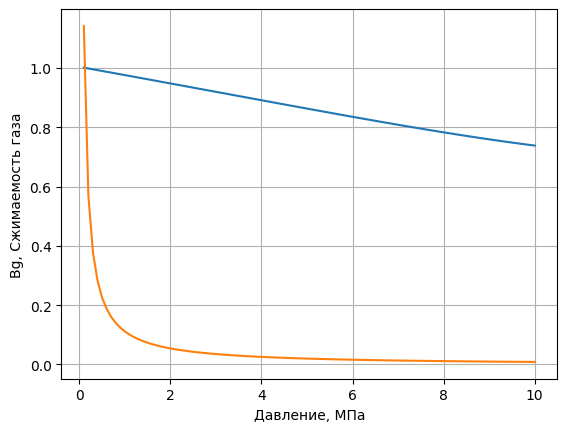

In [135]:
#Загрузка данных и проверка
import pandas as pd

# Загрузка данных
df = pd.read_csv('hw2_data.csv', sep=';', index_col=0)
display(df)

fluid = Fluid(1, 2, 3)

# Проверка: рассчитать Z и Bg при P = 50 атм, T = 310 К
P_test, T_test = 50, 310
z = fluid.get_Z(P_test, T_test)
bg = fluid.get_Bg(P_test, T_test)
# Построение графиков
fluid.plot_Z()
fluid.plot_Bg()

In [131]:
s = """Али Иван 
Альзейн Мохаммад Альжавад
Андреев Вячеслав Олегович
Гедымин Герман Константинович
Инюхин Дмитрий Романович
Котиев Муслим Магометович
Пугачев Александр Сергеевич
Пулидо Де Ла Крус Лианнес
Самохвалов Денис Александрович
Федореев Юрий Георгиевич
Хомурар Даниил Васильевич
Шабронов Алексей Сергеевич
Шайбаков Ислам Ренатович
Эрнандес Перес Луисмель
Слива Никита Владиславович
Алибаева Эмилия Ириковна
Каширин Егор Викторович"""

import numpy as np
import pandas as pd
np.random.seed(42)

data = []
for fio in s.split('\n'):
    d = {}
    xa = np.random.rand()
    xy = np.random.rand()
    d['student'] = fio
    d['xa, mol. %'] = round(xa,4)
    d['xy, mol. %'] = round(xy, 4)
    d['rho_c, kg/m3'] = 0.6799
    data.append(d)



# pd.DataFrame(data).to_csv('hw2_data.csv', sep = ';', encoding='utf-8-sig')